# Preprocess imaging data

## Import libraries

In [19]:
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
import numpy as np

from unityvr.preproc import logproc as lp
from unityvr.analysis import posAnalysis
from unityvr.viz import viz, utils
from gulp2p import utils as utils
from gulp2p import ImagingPreProc as iPP
from gulp2p import ROIs as ROIs

## Get file names for a given set of experiments

In [20]:
file_names = utils.loadFileNames()

## Preprocess data

### For each tif:
1. Create motion corrected MIPs
2. Specify the ROIs
3. Calculate the DF/F

### Specify parameters for motion correction

In [21]:
numRefImg = 50 # the number of images to average for the reference image
upsampleFactor = 20 # how much to upsample the image in order to shift the image by less than one pixel
sigma = 2 # the sigma to use in Gaussian filtering

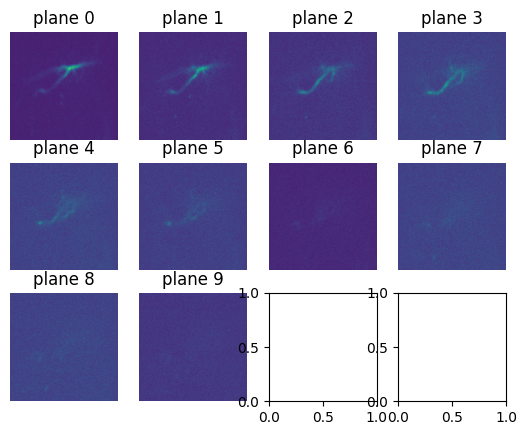

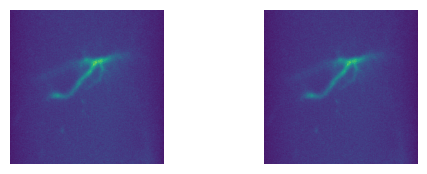

In [22]:
for i,file in enumerate(file_names):
    # Load the tif
    [stack, nCh, nDiscardFBFrames, fpv] = iPP.loadTif(file)

    # Plot the mean of each plane
    fig_mean_planes = iPP.plotMeanPlane(stack,col=0) # col=1 to plot the second channel if it exists
    
    # Specify the planes to use for the Maximum Intensity Projection (MIP)
    slices = iPP.getSlicesFromStack()
    
    # Calculate the MIP
    stack_MIP = iPP.stackToMIP(stack,slices)

    # Motion correct the MIP
    locRefImg = round(stack_MIP.shape[0]/12)# the initial position in the stack to use for the reference
    [shift, stack_MC] = iPP.tifMotionCorrect(numRefImg, locRefImg, upsampleFactor, np.squeeze(stack_MIP[:,0,:,:]), sigma)
    
    # Plot the before and after
    fig, axs = plt.subplots(ncols = 2, nrows = 1, figsize = (6,2))
    axs[0].imshow(stack_MIP[:,0,:,:].mean(axis=0))
    axs[0].axis('off')
    axs[1].imshow(stack_MC.mean(axis=0))
    axs[1].axis('off')
    
    # Get the ROIS - For EB wedges, there are a number of other possible ROI functions for different shapes
    if i == 0:
        [rois, allROIs, allMasks] = iPP.getROIs(stack_MC.mean(axis=0), ROIs.PolyROIs, [],'')
    else:
        [rois, allROIs, allMasks] = iPP.getROIs(stack_MC.mean(axis=0), ROIs.PolyROIs, rois, allMasks)
    
    # Get the raw fluorescence
    rawF_G = np.zeros((stack_MC.shape[0],len(allMasks)))
    for fm_num, frame in enumerate(stack_MC):
        for r in range(0,len(allMasks)):
            rawF_G[fm_num,r] = np.multiply(frame, allMasks[r]).sum()
    
    # Get the DF/F
    DF_G = iPP.DFoF(rawF_G)
    
    # Put all of the data into a dictionary
    exptDat = {'trialName':file.split('/')[-1][0:-4],
               'fpv': fpv,
               'meanMIP_G': np.squeeze(stack_MC.mean(axis=0)),
               'ROIOutlines': rois,
               'allROIs': allROIs,
               'rawF_G':rawF_G,
               'DF_G': DF_G
              }
    
    # Pickle and save the data
    outfile = open(file[0:-4] + '_DF.p', 'wb')
    pickle.dump(exptDat, outfile)
    outfile.close()

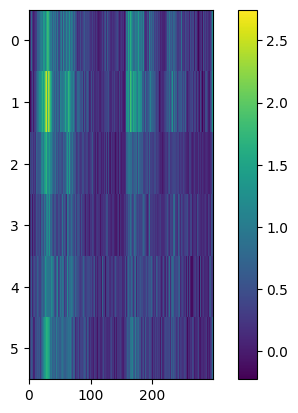

In [24]:
fig,ax = plt.subplots()
act = ax.imshow(DF_G.T, aspect = 100, interpolation="none")
fig.colorbar(act)
# plt.savefig(fig, dpi = 300, format ='svg')

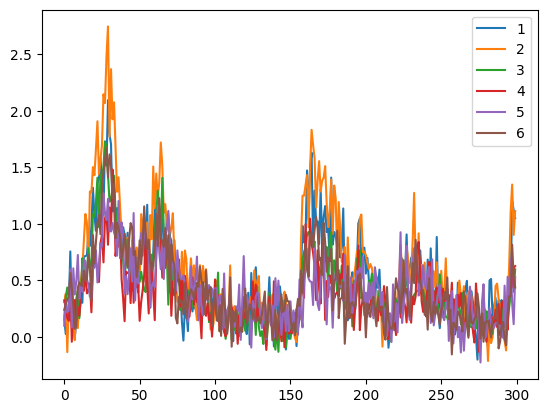

In [25]:
fig,ax = plt.subplots()
ax.plot(np.arange(0,len(DF_G)),DF_G)
ax.legend(labels = '123456')
